In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 1. 데이터 생성
- 남자, 여자의 키와 몸무게 데이터를 군집화

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [3]:
random.randint(40, 95) #40부터 95까지의 정수 중 하나를 무작위 선택 반환

77

In [6]:
data = []
for i in range(50):
    #여자 데이터
    data.append([random.randint(40, 70), random.randint(140, 170)])
    #남자 데이터
    data.append([random.randint(60, 95), random.randint(160, 195)])
#data

In [8]:
#여자
for female in data[:100:2]:
    print(female, end=' ')
#남자
print('\n-------------------------------')
for male in data [1::2]:
    print(male, end=' ')

[43, 160] [53, 145] [55, 155] [54, 156] [62, 142] [61, 166] [59, 142] [42, 169] [51, 165] [52, 156] [55, 147] [55, 158] [61, 167] [69, 146] [62, 140] [67, 163] [66, 148] [60, 156] [52, 170] [47, 163] [59, 167] [57, 169] [54, 145] [46, 154] [59, 150] [42, 148] [41, 156] [64, 157] [60, 165] [46, 142] [44, 160] [68, 160] [42, 147] [48, 160] [61, 146] [58, 142] [67, 155] [50, 144] [58, 170] [61, 150] [46, 142] [44, 147] [43, 169] [45, 149] [49, 157] [63, 148] [49, 164] [58, 166] [40, 146] [49, 153] 
-------------------------------
[91, 171] [88, 166] [76, 174] [80, 183] [80, 179] [87, 195] [85, 173] [89, 190] [69, 170] [93, 195] [95, 161] [94, 181] [87, 188] [63, 181] [75, 171] [73, 190] [82, 189] [91, 177] [81, 165] [82, 165] [60, 172] [81, 172] [64, 164] [76, 167] [71, 166] [66, 187] [81, 170] [71, 178] [93, 186] [79, 193] [77, 166] [63, 195] [65, 175] [69, 192] [60, 167] [63, 183] [90, 180] [68, 190] [65, 175] [84, 182] [78, 170] [92, 191] [68, 167] [91, 191] [70, 187] [85, 179] [60, 19

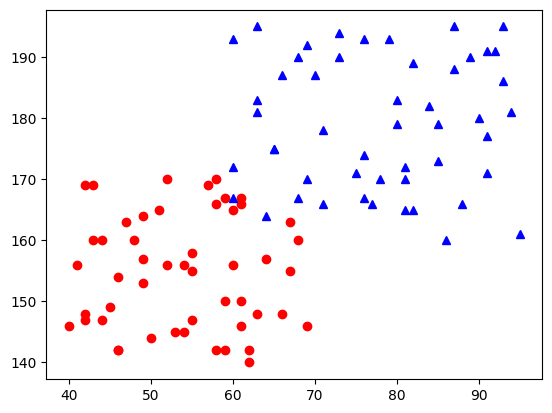

In [11]:
# print('여자 몸무게:', [d[0] for d in data[::2]])
# print('여자 키:', [d[1] for d in data[::2]])
# print('남자 몸무게:', [d[0] for d in data[1::2]])
# print('남자 키:', [d[1] for d in data[1::2]])
plt.plot([d[0] for d in data[::2]],
        [d[1] for d in  data[::2]], 'o', color='r')
plt.plot([d[0] for d in data[1::2]],
        [d[1] for d in  data[1::2]], '^', color='b')

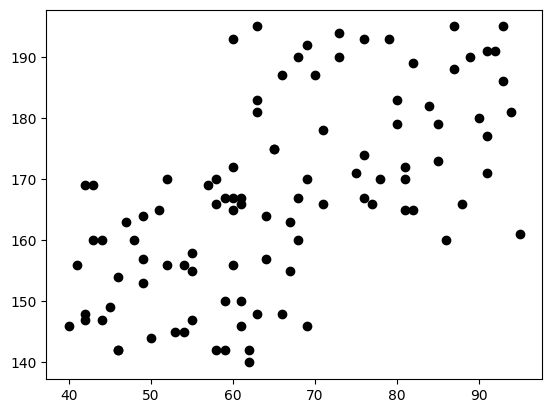

In [12]:
plt.plot([d[0] for d in data[::2]],
        [d[1] for d in  data[::2]], 'o', color='k')
plt.plot([d[0] for d in data[1::2]],
        [d[1] for d in  data[1::2]], 'o', color='k')

# 2. 군집화 로직

In [13]:
# 초기 랜덤지점 2개
random_point = [[random.randint(40, 95), random.randint(140, 195)],
                [random.randint(40, 95), random.randint(140, 195)]]
random_point

[[87, 168], [70, 141]]

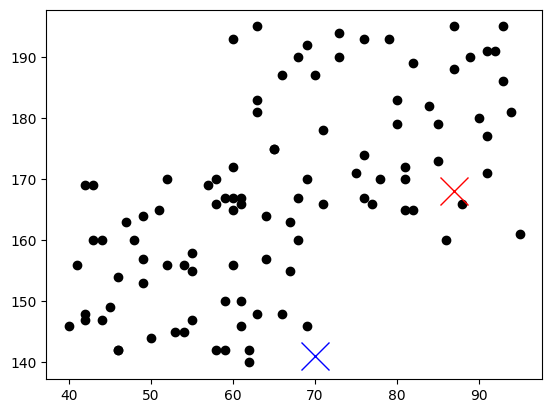

In [14]:
plt.plot([d[0] for d in data],
        [d[1] for d in data], 'o', color='k')
plt.plot(random_point[0][0],
        random_point[0][1], 'x', color='r', markersize=20) #기준점1
plt.plot(random_point[1][0],
        random_point[1][1], 'x', color='b', markersize=20) #기준점2

In [15]:
# 두 점의 거리를 return
def dist(a, b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2) #np.sqrt():루트

In [16]:
a = [0,0]; b=[4,3]
dist(a,b)

5.0

In [17]:
# 두 영역 random_point[0]과 random_point[1]을 기준으로 나눈 두 영역
group1 = [] #random_point[0]이 가까운 그룹
group2 = [] #random_point[1]이 가까운 그룹
for d in data:
    if dist(random_point[0], d) < dist(random_point[1], d):
        group1.append(d) #빨간X랑 더 가까운 그룹
    else:
        group2.append(d) #파란X랑 더 가까운 그룹
len(group1), len(group2)

(56, 44)

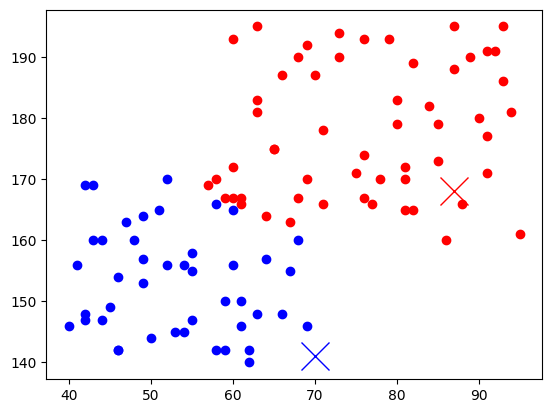

In [21]:
# 새로운 그룹group1과 group2, 초기 랜덤 지점
plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in group2], 'o', color='b')
plt.plot(random_point[0][0],
        random_point[0][1], 'x', color='r', markersize=20)
plt.plot(random_point[1][0],
        random_point[1][1], 'x', color='b', markersize=20)
plt.show()

In [27]:
# 기준점 이동 group1의 중심점, group2중심점
sumX=0; sumY=0
for g in group1:
    sumX+= g[0]
    sumY += g[1]
#새로운 기준점으로 할당
random_point[0] = [sumX/len(group1), sumY/len(group1)]
sumX=0; sumY=0
for g in group2:
    sumX += g[0]
    sumY += g[1]
#새로운 기준점으로 할당
random_point[1] = [sumX/len(group2), sumY/len(group2)]
random_point

[[75.875, 177.69642857142858], [53.04545454545455, 153.1818181818182]]

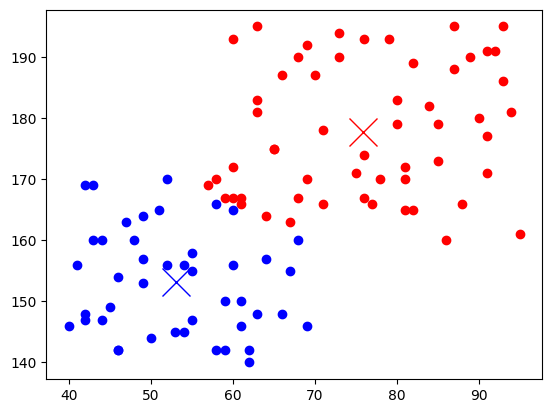

In [28]:
plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in group2], 'o', color='b')
plt.plot(random_point[0][0],
        random_point[0][1], 'x', color='r', markersize=20)
plt.plot(random_point[1][0],
        random_point[1][1], 'x', color='b', markersize=20)
plt.show()

# 3. 전체 코드(for문 이용)
- data 생성
- 랜덤포인트2지점
- for문
    - 랜덤포인트 2지점기준으로 group1과 group2
    - 랜덤포인트 이용(group1중간점, group2중간점)

초기 points :  [[87, 155], [71, 159]]
1 번째 points :  [[90.125, 177.8125], [61.11904761904762, 164.63095238095238]]
2 번째 points :  [[83.5625, 182.0625], [57.38235294117647, 159.52941176470588]]
3 번째 points :  [[80.04761904761905, 181.02380952380952], [55.41379310344828, 156.39655172413794]]
4 번째 points :  [[78.95652173913044, 180.2391304347826], [54.51851851851852, 155.24074074074073]]
5 번째 points :  [[78.41666666666667, 179.77083333333334], [54.07692307692308, 154.71153846153845]]
6 번째 points :  [[78.41666666666667, 179.77083333333334], [54.07692307692308, 154.71153846153845]]
7 번째 points :  [[78.41666666666667, 179.77083333333334], [54.07692307692308, 154.71153846153845]]
8 번째 points :  [[78.41666666666667, 179.77083333333334], [54.07692307692308, 154.71153846153845]]
9 번째 points :  [[78.41666666666667, 179.77083333333334], [54.07692307692308, 154.71153846153845]]
10 번째 points :  [[78.41666666666667, 179.77083333333334], [54.07692307692308, 154.71153846153845]]


(140.0, 195.0)

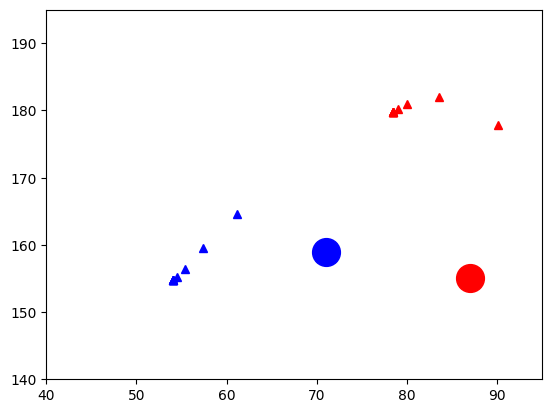

In [40]:
data = []
for i in range(50):
    #여자 데이터
    data.append([random.randint(40, 70), random.randint(140, 170)])
    #남자 데이터
    data.append([random.randint(60, 95), random.randint(160, 195)])
#point지정
points = [[random.randint(40,95), random.randint(140,195)],
          [random.randint(40,95), random.randint(140,195)]]
print("초기 points : ", points)
plt.plot(points[0][0], points[0][1], 'o', c='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'o', c='b', markersize=20)
#포인트 2지점기준으로 group1과 group2
for i in range(1, 11):
    group1 = [] # points[0]과 가까운 그룹
    group2 = [] # points[1]과 가까운 그룹
    for d in data:
        if dist(d, points[0]) < dist(d, points[1]):
            group1.append(d)
        else:
            group2.append(d)
    # 새로운 포인트로 할당
    sumX = 0; sumY=0
    for g in group1:
        sumX += g[0]
        sumY += g[1]
    points[0] = [sumX/len(group1), sumY/len(group1)]
    sumX = 0; sumY=0
    for g in group2:
        sumX += g[0]
        sumY += g[1]
    points[1] = [sumX/len(group2), sumY/len(group2)]
    print(i, "번째 points : ", points)
    plt.plot(points[0][0], points[0][1], '^', c='r')
    plt.plot(points[1][0], points[1][1], '^', c='b')
plt.xlim([40, 95])
plt.ylim([140, 195])

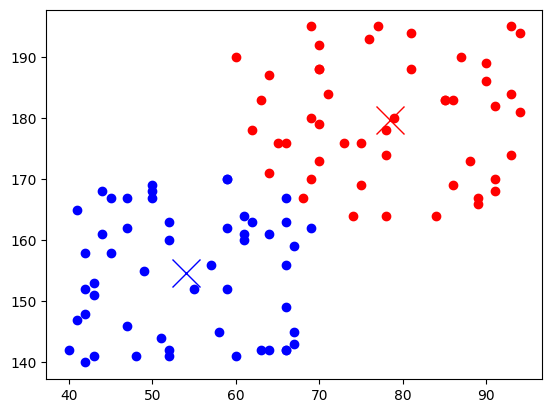

In [44]:
plt.plot([d[0] for d in group1],
        [d[1] for d in group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in group2], 'o', color='b')
plt.plot(points[0][0], points[0][1], 'x', color='r', markersize=20)
plt.plot(points[1][0], points[1][1], 'x', color='b', markersize=20)

# 4. api(sklearn)를 이용한 군집화
- sklearn 머신러닝
     * 예측함수
         ; 분류, 회귀, 군집분석
         fit(학습), predict(예측)
     * 변환함수(전처리함수)
         ; 전처리 ex. 스케일조정
         fit(학습), transform(변환함수)

In [45]:
# 군집분석 라이브러리가 joblib충돌 경고 메세지 출력
import os
os.environ["OMP_NUM_THREAS"] = "1"

In [48]:
data = np.array(data)
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, #2개 그룹으로 나눠
               init='random', #초기 중심점 랜덤하게
               n_init=10, #10번 실행
               random_state=7 #중심점 세팅
              )
model.fit(data)

KMeans(init='random', n_clusters=2, n_init=10, random_state=7)

In [49]:
# 중심점
model.cluster_centers_

array([[ 78.41666667, 179.77083333],
       [ 54.07692308, 154.71153846]])

In [50]:
# 나눠진 그룹들의 인덱스
model.labels_

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0])

In [53]:
group1 = data[model.labels_==1]
group2 = data[model.labels_==0]
c1, c2= model.cluster_centers_

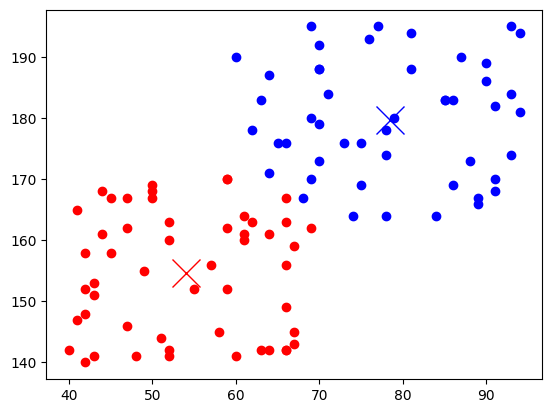

In [57]:
plt.plot([d[0] for d in group1],
        [d[1] for d in  group1], 'o', color='r')
plt.plot([d[0] for d in group2],
        [d[1] for d in  group2], 'o', color='b')
plt.plot(c1[0], c1[1], 'x', color='b', markersize=20)
plt.plot(c2[0], c2[1], 'x', color='r', markersize=20)